# Statsmodels

In [4]:
!pip install prophet

Saving dummy_meter_readings_200.csv to dummy_meter_readings_200 (1).csv
Training the Advanced ML Model with Tiered Rates...
Training Complete!

--- Future Forecast (Next 6 Months) ---
           ds           yhat     yhat_lower     yhat_upper
35 2025-11-30   16190.161081   15905.423516   16453.862552
36 2025-12-31 -185943.230218 -186225.657858 -185644.253989
37 2026-01-31   15653.954202   15384.954717   15929.121972
38 2026-02-28   15964.302064   15698.934762   16228.250353
39 2026-03-31   14460.368868   14203.487432   14730.657927
40 2026-04-30  -74464.526058  -74744.994160  -74177.925665


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


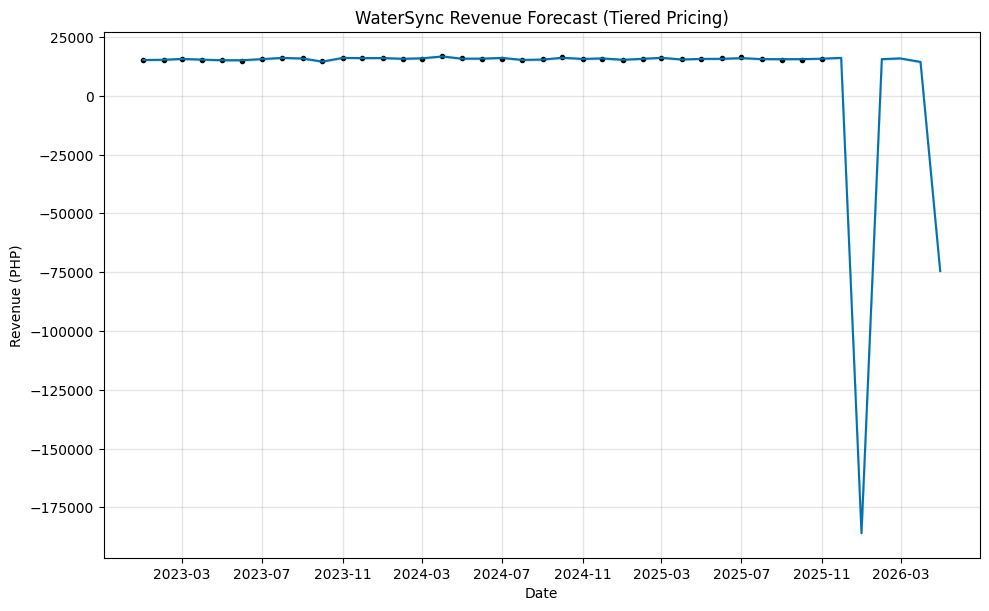

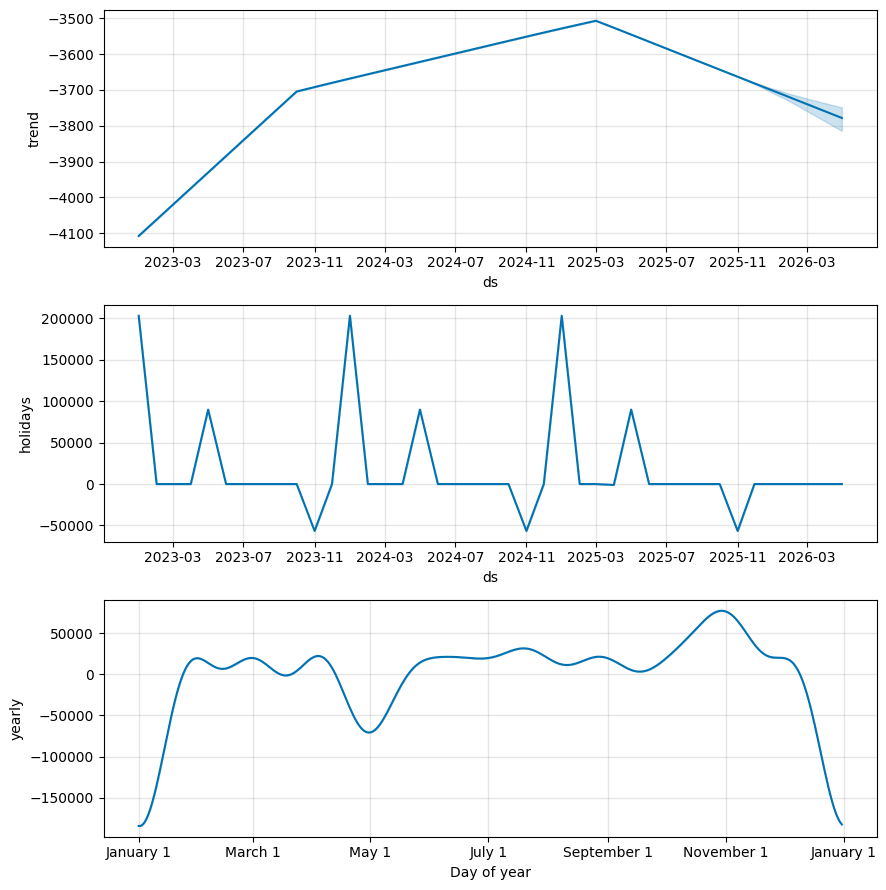


Packaging and downloading the updated AI model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered successfully!


In [5]:
import pandas as pd
from prophet import Prophet
from prophet.serialize import model_to_json
import matplotlib.pyplot as plt
import json
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
df['Consumption'] = df['Current Reading'] - df['Previous Reading']

def calculate_revenue(consumption):
    if consumption <= 6:
        return 100.0
    else:
        return 100.0 + ((consumption - 6) * 20.0)

df['Revenue'] = df['Consumption'].apply(calculate_revenue)
df['Reading Date'] = pd.to_datetime(df['Reading Date'])

monthly_data = df.groupby(df['Reading Date'].dt.to_period('M'))['Revenue'].sum().reset_index()
monthly_data['Reading Date'] = monthly_data['Reading Date'].dt.to_timestamp()

prophet_df = pd.DataFrame({
    'ds': monthly_data['Reading Date'],
    'y': monthly_data['Revenue']
})

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.add_country_holidays(country_name='PH')

print("Training the Advanced ML Model with Tiered Rates...")
model.fit(prophet_df)
print("Training Complete!\n")

future_calendar = model.make_future_dataframe(periods=6, freq='M')
forecast = model.predict(future_calendar)

print("--- Future Forecast (Next 6 Months) ---")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6))

fig1 = model.plot(forecast)
plt.title("WaterSync Revenue Forecast (Tiered Pricing)")
plt.xlabel("Date")
plt.ylabel("Revenue (PHP)")
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

print("\nPackaging and downloading the updated AI model...")
with open('watersync_prophet_model.json', 'w') as fout:
    json.dump(model_to_json(model), fout)

files.download('watersync_prophet_model.json')
print("Download triggered successfully!")

Training the Advanced ML Model...
Training Complete!



/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


--- Future Forecast (Next 6 Months) ---
           ds           yhat     yhat_lower     yhat_upper
35 2025-11-30   19780.901037   19344.813058   20208.097347
36 2025-12-31 -204419.498508 -204831.742575 -203976.384760
37 2026-01-31   19249.100808   18821.874459   19696.841905
38 2026-02-28   19884.091534   19459.473682   20353.127666
39 2026-03-31   18677.814012   18235.567881   19118.394664
40 2026-04-30  -28835.745862  -29264.059049  -28342.469275


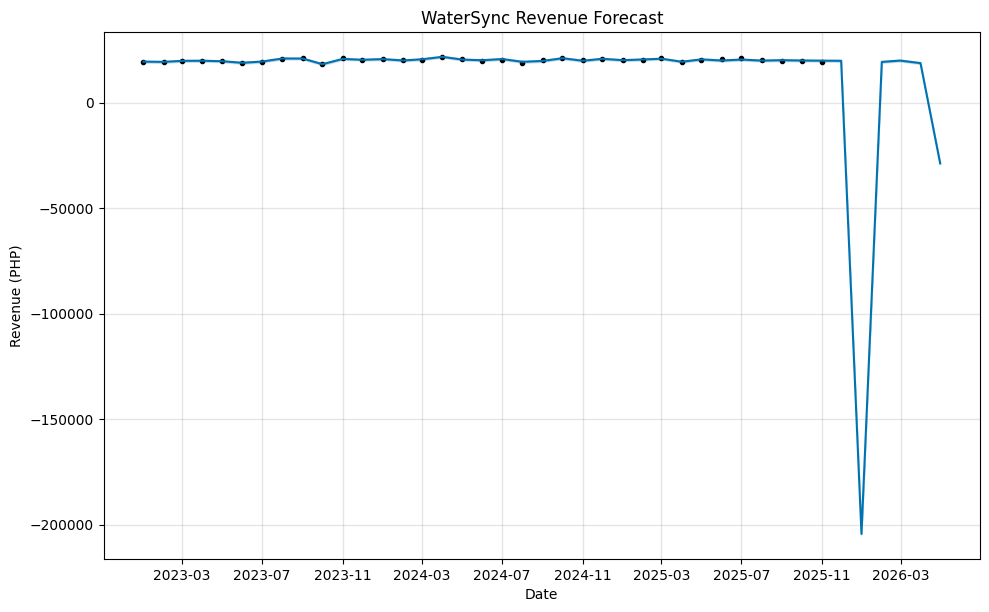

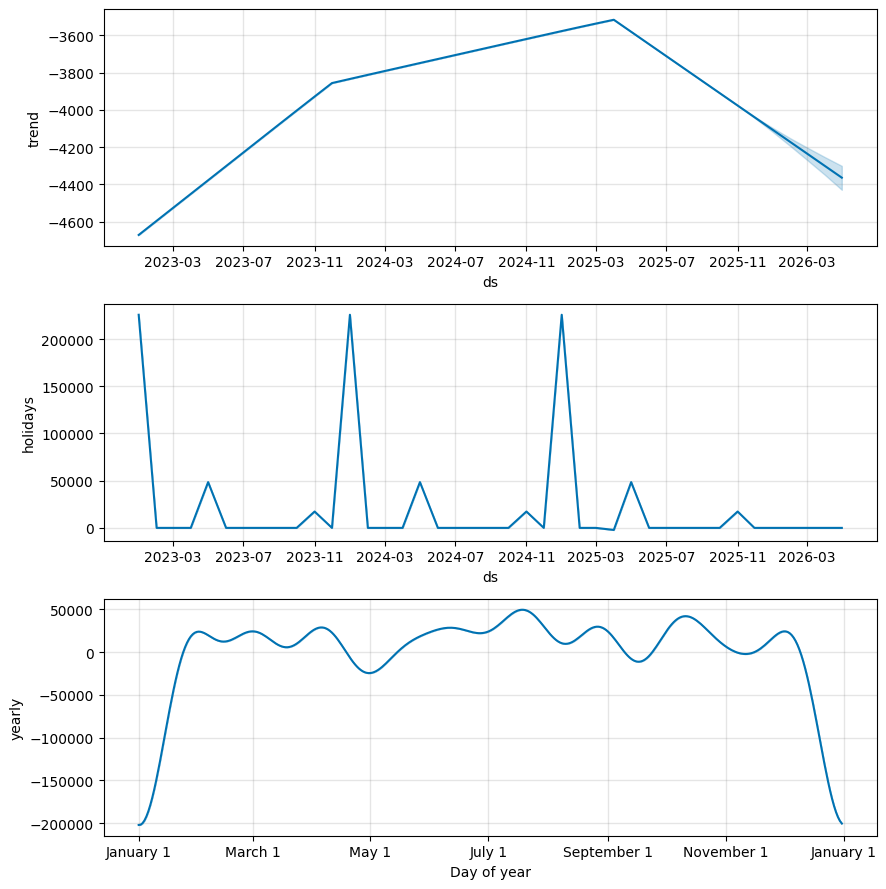

INFO:prophet:Making 28 forecasts with cutoffs between 2023-07-15 00:00:00 and 2025-10-02 00:00:00



Running Accuracy Tests (Cross-Validation)... This may take a moment.


  0%|          | 0/28 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 4.
INFO:prophet:n_changepoints greater than number of observations. Using 5.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 9.
INFO:prophet:n_changepoints greater than number of observations. Using 10.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 12.
INFO:prophet:n_changepoints greater than number of observations. Using 13.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints grea


--- AI Accuracy Metrics ---
  horizon           rmse      mape
0 18 days  194531.689162  8.997831
1 19 days  134220.167833  5.889538
2 20 days   45487.957608  1.614478
3 21 days    5810.571452  0.237021
4 22 days    9306.734696  0.356484


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


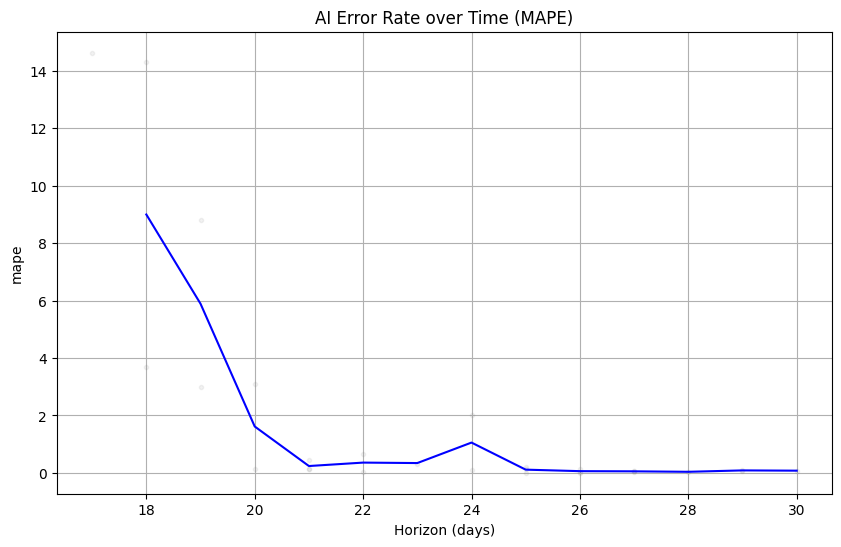

In [6]:
import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt

df = pd.read_csv('dummy_meter_readings_200.csv')
df['Consumption'] = df['Current Reading'] - df['Previous Reading']
df['Revenue'] = df['Consumption'] * 25.0
df['Reading Date'] = pd.to_datetime(df['Reading Date'])

monthly_data = df.groupby(df['Reading Date'].dt.to_period('M'))['Revenue'].sum().reset_index()
monthly_data['Reading Date'] = monthly_data['Reading Date'].dt.to_timestamp()

prophet_df = pd.DataFrame({
    'ds': monthly_data['Reading Date'],
    'y': monthly_data['Revenue']
})

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.add_country_holidays(country_name='PH')

print("Training the Advanced ML Model...")
model.fit(prophet_df)
print("Training Complete!\n")

future_calendar = model.make_future_dataframe(periods=6, freq='M')
forecast = model.predict(future_calendar)

print("--- Future Forecast (Next 6 Months) ---")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6))

fig1 = model.plot(forecast)
plt.title("WaterSync Revenue Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue (PHP)")
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

print("\nRunning Accuracy Tests (Cross-Validation)... This may take a moment.")
try:
    df_cv = cross_validation(model, initial='180 days', period='30 days', horizon='30 days')
    df_p = performance_metrics(df_cv)

    print("\n--- AI Accuracy Metrics ---")
    print(df_p[['horizon', 'rmse', 'mape']].head())

    fig3 = plot_cross_validation_metric(df_cv, metric='mape')
    plt.title("AI Error Rate over Time (MAPE)")
    plt.show()

except Exception as e:
    print("\nNote: Not enough years of dummy data to run Cross-Validation testing.")
    print("Add more historical months to your CSV to unlock Accuracy Testing!")

Statsmodels is a Python module that allows users to explore data, estimate statistical models, and perform statistical tests. An extensive list of descriptive statistics, statistical tests, plotting functions, and result statistics are available for different types of data and each estimator.

Library documentation: <a>http://statsmodels.sourceforge.net/</a>